# Trabalho de Ciência de Dados  
## Classificação da qualidade de cervejas com Python

Este trabalho tem como objetivo aplicar técnicas de Ciência de Dados para classificar a qualidade de cervejas com base em avaliações reais.

Serão utilizados três algoritmos de Machine Learning:
- **Naive Bayes**
- **Árvore de Decisão**
- **Random Forest**

A classificação será feita em duas categorias:
- **Comum**
- **Excelente**

## Base de dados utilizada

A base utilizada foi o **Beer Reviews Dataset**, disponível no Kaggle:  
https://www.kaggle.com/datasets/rdoume/beerreviews

A base contém avaliações de cervejas com atributos como aroma, paladar, teor alcoólico e nota geral.

Para uso no Google Colab, o arquivo `beer_reviews.csv` pode ser:
1. carregado manualmente no ambiente, ou
2. armazenado no Google Drive para leitura automática.

Devido ao grande volume de dados, foi utilizada uma **amostragem de 1%**, mantendo eficiência sem comprometer a análise.

## 1. Importação de bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para leitura da base, manipulação dos dados, visualização e treinamento dos modelos.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Carregamento da base

O código tenta carregar automaticamente o arquivo `beer_reviews.csv`, procurando primeiro no ambiente atual, depois solicitando upload manual.

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

arquivo = list(uploaded.keys())[0]

df_original = pd.read_csv(arquivo)

print("Base original carregada com sucesso.")
print(f"Quantidade de registros da base original: {len(df_original):,}")
print(f"Quantidade de colunas: {df_original.shape[1]}")

Saving beer_reviews.csv to beer_reviews.csv
Base original carregada com sucesso.
Quantidade de registros da base original: 1,586,614
Quantidade de colunas: 13


## 3. Amostragem

Como a base original é muito grande, foi utilizada apenas uma amostra de **1%** dos registros para reduzir custo computacional e tornar a execução mais prática no Colab.

In [ ]:
df = df_original.sample(frac=0.01, random_state=42).copy()
df.to_csv("beer_reviews_sampled.csv", index=False)

print("Amostragem realizada com sucesso.")
print("Total de registros na amostra:", len(df))

Amostragem realizada com sucesso.
Total de registros na amostra: 15866


## 4. Visão geral da base

Antes da modelagem, é importante verificar a estrutura da base, os tipos de dados e a presença de valores ausentes.

In [ ]:
print("Informações gerais da base:")
df.info()

Informações gerais da base:
<class 'pandas.core.frame.DataFrame'>
Index: 15866 entries, 859964 to 189558
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brewery_id          15866 non-null  int64  
 1   brewery_name        15866 non-null  object 
 2   review_time         15866 non-null  int64  
 3   review_overall      15866 non-null  float64
 4   review_aroma        15866 non-null  float64
 5   review_appearance   15866 non-null  float64
 6   review_profilename  15865 non-null  object 
 7   beer_style          15866 non-null  object 
 8   review_palate       15866 non-null  float64
 9   review_taste        15866 non-null  float64
 10  beer_name           15866 non-null  object 
 11  beer_abv            15211 non-null  float64
 12  beer_beerid         15866 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 1.7+ MB


In [ ]:
print("Primeiras linhas da base:")
display(df.head())

Primeiras linhas da base:


,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
859964,13307,Mikkeller ApS,1317606533,4.0,4.5,4.5,Ghenna,American Barleywine,3.5,3.5,Big Worst,18.5,56831
581443,126,Pete's Brewing Company,1195281294,2.5,3.0,3.5,hwwty4,Cream Ale,3.0,2.5,Pete's Wicked Wanderlust Cream Ale,5.6,19950
1270456,203,Greene King / Morland Brewery,1224109943,4.0,3.5,4.0,dsa7783,English Pale Ale,3.5,3.5,Abbot Ale,5.0,910
477415,167,Brewery Lobkowicz,1070489226,4.5,4.0,3.5,TastyTaste,Czech Pilsener,4.0,4.5,Lobkowicz Knight,4.8,444
1408999,664,Wells & Young's Ltd,1172208746,5.0,4.0,5.0,BadRockBeer,Milk / Sweet Stout,5.0,5.0,Young's Double Chocolate Stout,5.2,73


In [ ]:
print("Valores ausentes por coluna:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

Valores ausentes por coluna:


,0
beer_abv,655
review_profilename,1
review_time,0
brewery_name,0
brewery_id,0
review_aroma,0
review_overall,0
beer_style,0
review_appearance,0
review_palate,0


## 5. Ajuste dos nomes das colunas

Algumas colunas foram renomeadas para facilitar a leitura e a apresentação dos resultados.

In [ ]:
df = df.rename(columns={
    "review_overall": "nota",
    "review_aroma": "aroma",
    "review_palate": "paladar",
    "beer_abv": "teor_alcoolico"
})

print("Colunas principais ajustadas com sucesso.")

Colunas principais ajustadas com sucesso.


## 6. Criação da variável alvo

A variável `qualidade` foi criada a partir da nota geral:
- **1 = Excelente**, quando a nota é maior ou igual a 4.0
- **0 = Comum**, quando a nota é menor que 4.0

Isso permite tratar o problema como uma **classificação binária supervisionada**.

In [ ]:
df["qualidade"] = (df["nota"] >= 4.0).astype(int)

print("Distribuição da variável alvo:")
display(df["qualidade"].value_counts())

Distribuição da variável alvo:


,count
qualidade,
1,9966
0,5900


## 7. Distribuição da variável alvo

O gráfico abaixo mostra a distribuição das classes **Comum** e **Excelente**.

Essa verificação é importante para entender se há equilíbrio entre as classes, já que distribuições muito desbalanceadas podem afetar o desempenho dos modelos.

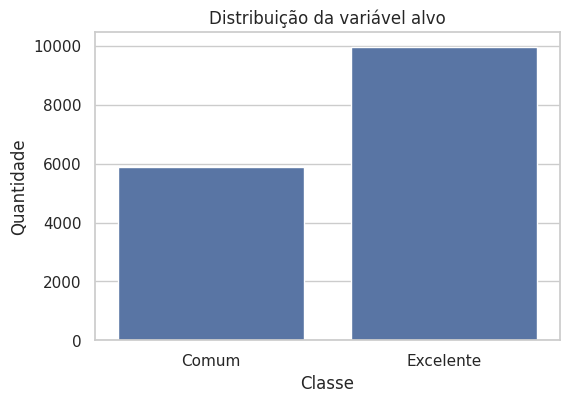

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["qualidade"])
plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Comum", "Excelente"])
plt.show()

A partir desse gráfico, é possível observar se a base apresenta maior concentração em uma das classes, o que pode influenciar a interpretação das métricas.

## 8. Seleção das variáveis explicativas

Foram selecionadas três variáveis numéricas para prever a qualidade:
- `teor_alcoolico`
- `aroma`
- `paladar`

Valores ausentes foram preenchidos com a mediana para evitar perda de registros.

In [ ]:
features = ["teor_alcoolico", "aroma", "paladar"]

X = df[features].fillna(df[features].median())
y = df["qualidade"]

print("Resumo estatístico das variáveis utilizadas:")
display(X.describe())

Resumo estatístico das variáveis utilizadas:


,teor_alcoolico,aroma,paladar
count,15866.000000,15866.000000,15866.000000
mean,7.014910,3.741428,3.753372
std,2.272729,0.691648,0.676234
min,0.400000,1.000000,1.000000
25%,5.300000,3.500000,3.500000
50%,6.500000,4.000000,4.000000
75%,8.400000,4.000000,4.000000
max,41.000000,5.000000,5.000000


## 9. Separação entre treino e teste

A base foi dividida em:
- **80% para treino**
- **20% para teste**

Também foi utilizado `random_state=42` para reprodutibilidade e `stratify=y` para preservar a proporção entre as classes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test.to_csv("X_test_python.csv", index=False)
y_test.to_csv("y_test_python.csv", index=False)

print("Divisão treino/teste concluída.")
print("Registros de treino:", len(X_train))
print("Registros de teste:", len(X_test))

Divisão treino/teste concluída.
Registros de treino: 12692
Registros de teste: 3174


## 10. Função de avaliação dos modelos

Foi criada uma função para padronizar a avaliação dos algoritmos.  
Ela treina o modelo, gera previsões e calcula:
- **Acurácia**
- **Precisão**
- **Recall**
- **F1-score**
- **Matriz de confusão**

In [ ]:
def avaliar_modelo(modelo, nome):
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    print(f"\n{nome}")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("\nRelatório de classificação:")
    print(classification_report(y_test, pred, target_names=["Comum", "Excelente"], zero_division=0))

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Comum", "Excelente"],
                yticklabels=["Comum", "Excelente"])
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

    return {
        "Modelo": nome,
        "Acurácia": acc,
        "Precisão": prec,
        "Recall": rec,
        "F1-score": f1
    }

## 11. Avaliação dos modelos

Os modelos serão comparados com base nas métricas calculadas.  
Essa etapa permite identificar não apenas o modelo com maior acurácia, mas também aquele com melhor equilíbrio entre precisão e recall.

### Naive Bayes

O Naive Bayes é um modelo probabilístico simples e rápido, útil como referência inicial.


Naive Bayes
Acurácia: 0.7820
Precisão: 0.7848
Recall:   0.8997
F1-score: 0.8383

Relatório de classificação:
              precision    recall  f1-score   support

       Comum       0.77      0.58      0.67      1180
   Excelente       0.78      0.90      0.84      1994

    accuracy                           0.78      3174
   macro avg       0.78      0.74      0.75      3174
weighted avg       0.78      0.78      0.77      3174



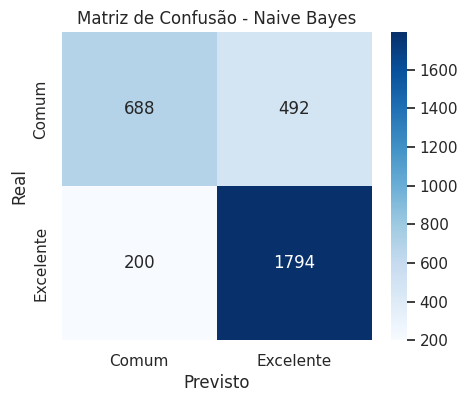

In [ ]:
resultado_nb = avaliar_modelo(GaussianNB(), "Naive Bayes")

### Árvore de Decisão

A Árvore de Decisão se destaca pela interpretabilidade, pois permite visualizar as regras utilizadas na classificação.


Árvore de Decisão
Acurácia: 0.7836
Precisão: 0.8107
Recall:   0.8551
F1-score: 0.8323

Relatório de classificação:
              precision    recall  f1-score   support

       Comum       0.73      0.66      0.69      1180
   Excelente       0.81      0.86      0.83      1994

    accuracy                           0.78      3174
   macro avg       0.77      0.76      0.76      3174
weighted avg       0.78      0.78      0.78      3174



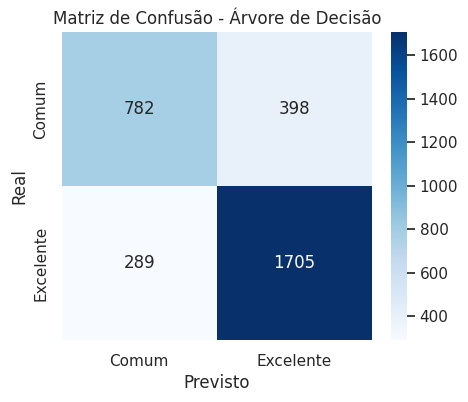

In [ ]:
resultado_arvore = avaliar_modelo(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    "Árvore de Decisão"
)

### Random Forest

O Random Forest combina várias árvores de decisão, o que geralmente aumenta a robustez e reduz a sensibilidade a variações do conjunto de dados.


Random Forest
Acurácia: 0.7735
Precisão: 0.8003
Recall:   0.8521
F1-score: 0.8254

Relatório de classificação:
              precision    recall  f1-score   support

       Comum       0.72      0.64      0.68      1180
   Excelente       0.80      0.85      0.83      1994

    accuracy                           0.77      3174
   macro avg       0.76      0.75      0.75      3174
weighted avg       0.77      0.77      0.77      3174



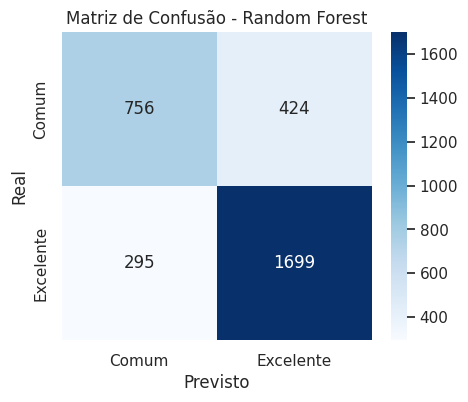

In [ ]:
resultado_rf = avaliar_modelo(
    RandomForestClassifier(n_estimators=100, random_state=42),
    "Random Forest"
)

## 12. Tabela comparativa final

A tabela abaixo reúne os resultados dos três algoritmos, facilitando a comparação entre eles.

In [ ]:
resultados = pd.DataFrame([resultado_nb, resultado_arvore, resultado_rf])
resultados = resultados.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

for col in ["Acurácia", "Precisão", "Recall", "F1-score"]:
    resultados[col] = resultados[col].round(4)

display(resultados)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Naive Bayes,0.7820,0.7848,0.8997,0.8383
1,Árvore de Decisão,0.7836,0.8107,0.8551,0.8323
2,Random Forest,0.7735,0.8003,0.8521,0.8254


Essa tabela permite observar qual modelo apresentou melhor desempenho geral e qual teve melhor equilíbrio entre as métricas avaliadas.

## 13. Gráfico comparativo das métricas

O gráfico abaixo mostra o desempenho dos modelos lado a lado em termos de acurácia, precisão, recall e F1-score.

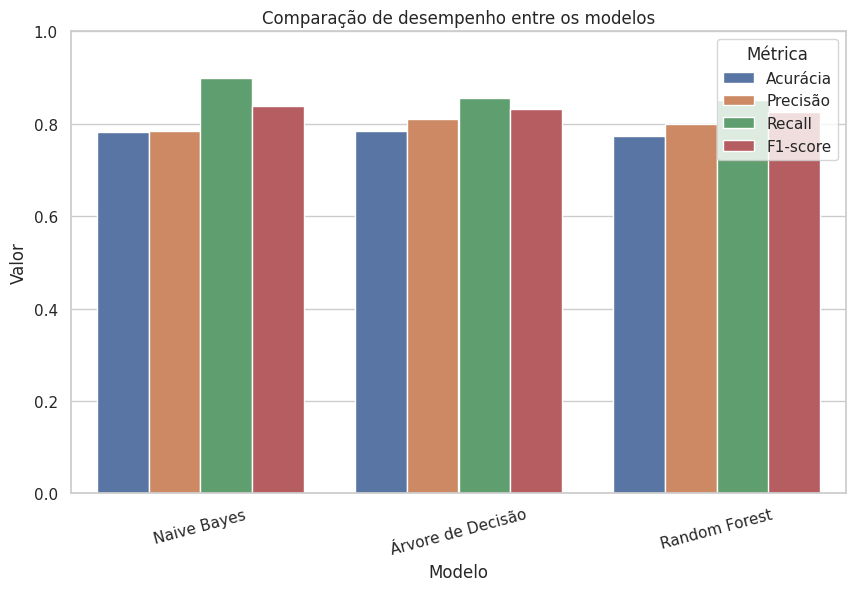

In [ ]:
resultados_melt = resultados.melt(
    id_vars="Modelo",
    value_vars=["Acurácia", "Precisão", "Recall", "F1-score"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=resultados_melt, x="Modelo", y="Valor", hue="Métrica")
plt.title("Comparação de desempenho entre os modelos")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

Essa visualização facilita a identificação do modelo com melhor desempenho geral e ajuda na interpretação comparativa dos resultados.

## 14. Visualização da árvore de decisão

Uma árvore com profundidade menor foi gerada para facilitar a leitura visual das regras.

Isso ajuda na discussão sobre **interpretabilidade**, mostrando como o modelo toma decisões com base nas variáveis de entrada.

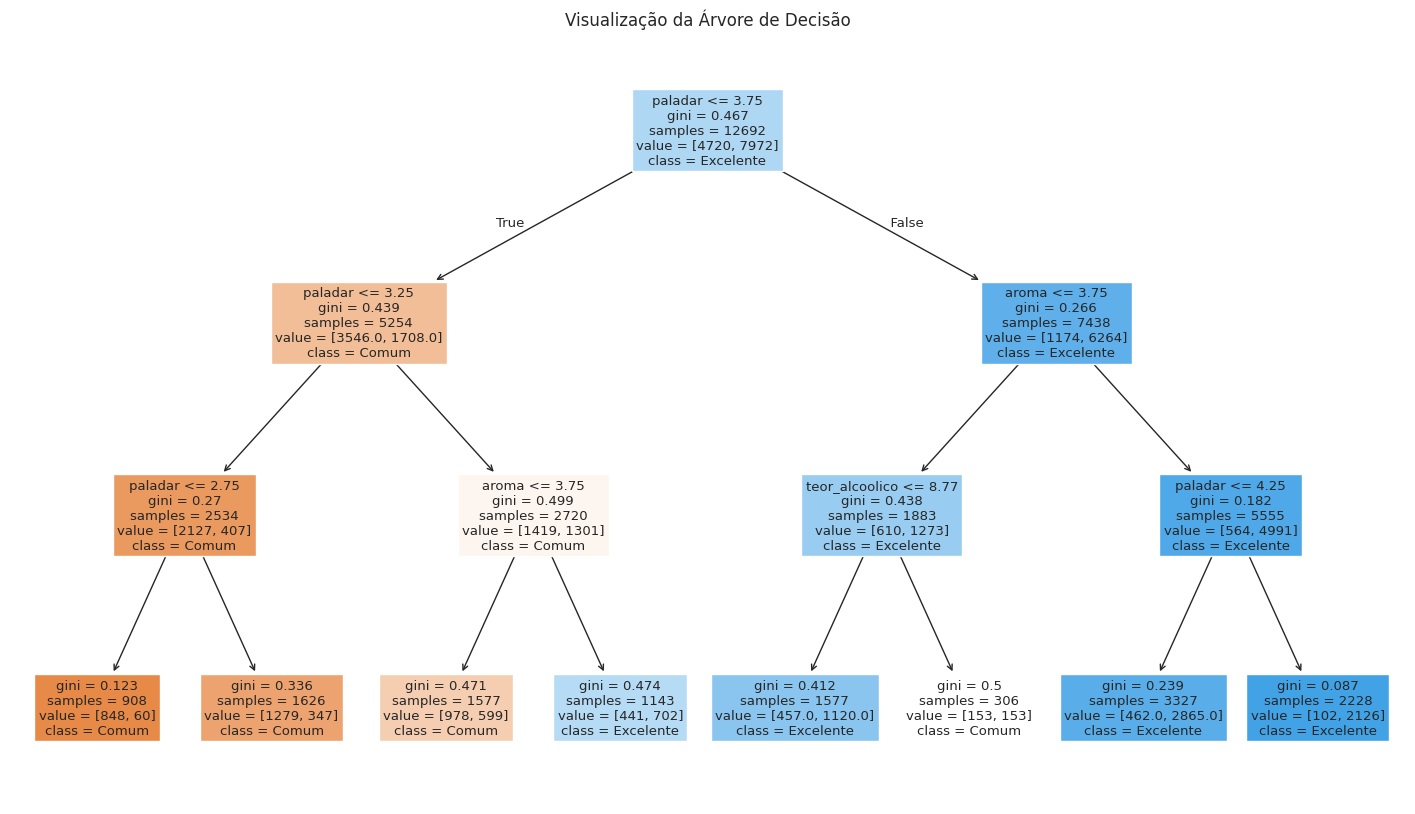

In [ ]:
modelo_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_tree.fit(X_train, y_train)

plt.figure(figsize=(18, 10))
plot_tree(
    modelo_tree,
    feature_names=features,
    class_names=["Comum", "Excelente"],
    filled=True
)
plt.title("Visualização da Árvore de Decisão")
plt.show()

Observando a árvore, é possível identificar quais variáveis aparecem com maior frequência nas divisões e como elas influenciam a classificação final.

## 15. Importância das variáveis no Random Forest

O gráfico abaixo mostra o peso relativo de cada variável no modelo Random Forest.

Essa análise ajuda a entender quais atributos mais contribuíram para prever a qualidade das cervejas.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
display(importancias)

,0
paladar,0.438552
aroma,0.297173
teor_alcoolico,0.264275


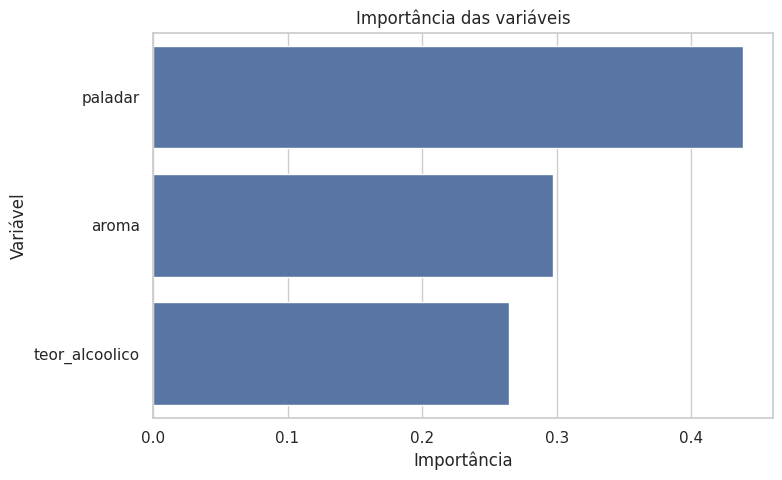

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title("Importância das variáveis")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()

Variáveis com maior importância exercem maior influência no processo de decisão do modelo.

## 16. Conclusão automática da etapa em Python

Com base no F1-score, o notebook identifica automaticamente o modelo com melhor desempenho.  
Essa conclusão serve como apoio, mas a interpretação final deve considerar também a robustez e a interpretabilidade de cada algoritmo.

In [ ]:
melhor_modelo = resultados.iloc[0]

print("Modelo com melhor F1-score:", melhor_modelo["Modelo"])
print("Resumo:")
print("- O Random Forest tende a ser mais robusto.")
print("- A Árvore de Decisão facilita a interpretação.")
print("- O Naive Bayes funciona como baseline simples e eficiente.")

Modelo com melhor F1-score: Naive Bayes
Resumo:
- O Random Forest tende a ser mais robusto.
- A Árvore de Decisão facilita a interpretação.
- O Naive Bayes funciona como baseline simples e eficiente.


## 17. Exportação dos resultados

Os principais arquivos gerados são exportados para facilitar a organização da entrega e o reaproveitamento posterior.

In [ ]:
resultados.to_csv("resultados_modelos_python.csv", index=False, encoding="utf-8-sig")
importancias.to_csv("importancia_variaveis_random_forest.csv", encoding="utf-8-sig")

print("Arquivos gerados com sucesso:")
print("- beer_reviews_sampled.csv")
print("- X_test_python.csv")
print("- y_test_python.csv")
print("- resultados_modelos_python.csv")
print("- importancia_variaveis_random_forest.csv")

Arquivos gerados com sucesso:
- beer_reviews_sampled.csv
- X_test_python.csv
- y_test_python.csv
- resultados_modelos_python.csv
- importancia_variaveis_random_forest.csv
